## Baixando bibliotecas

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('ggplot')

## Baixando bases de dados

In [2]:
df = pd.read_csv("../../1_limpeza_de_dados/databases/avaliacoes_Docentes_Turmas.csv", sep = ";")

# Visualizando


In [8]:
# Criando variável de total de reprovacoes
df['total_reprovacoes'] = (df['qtd_reprovado_por_nota'] + 
                          df['qtd_reprovado_por_faltas'] +
                          df['qtd_reprovado_por_nota_e_falta'] +
                          df['qtd_reprovado_por_média_e_por_faltas'])

# Criar variável binária: tem reprovação ou não
df['tem_reprovacao'] = df['total_reprovacoes'] > 0

# Criar categorias baseadas na presença e intensidade de reprovações
df['categoria_reprovacao'] = 'Nenhuma reprovação'
df.loc[df['tem_reprovacao'], 'categoria_reprovacao'] = 'Baixa reprovação (1-2 alunos)'
df.loc[df['total_reprovacoes'] > 2, 'categoria_reprovacao'] = 'Alta reprovação (3+ alunos)'

# Calcular taxa de reprovação apenas para turmas com reprovações
df['taxa_reprovacao'] = np.where(df['total_reprovacoes'] > 0, 
                                df['total_reprovacoes'] / df['qtd_discentes'], 
                                0)

In [9]:
print("Distribuição das categorias de reprovação:")
print(df['categoria_reprovacao'].value_counts())
print(f"\nTotal de turmas: {len(df)}")
print(f"Turmas com alguma reprovação: {df['tem_reprovacao'].sum()} ({df['tem_reprovacao'].mean()*100:.1f}%)")

# Estatísticas descritivas por grupo
variaveis_avaliacao = ['media_final_geral', 'postura_profissional_media', 
                      'atuacao_profissional_media', 'autoavaliacao_aluno_media']

for var in variaveis_avaliacao:
    print(f"\n--- {var} ---")
    stats = df.groupby('categoria_reprovacao')[var].agg(['mean', 'std', 'count'])
    print(stats)

Distribuição das categorias de reprovação:
categoria_reprovacao
Nenhuma reprovação               88095
Baixa reprovação (1-2 alunos)    21257
Alta reprovação (3+ alunos)      16942
Name: count, dtype: int64

Total de turmas: 126294
Turmas com alguma reprovação: 38199 (30.2%)

--- media_final_geral ---
                                   mean       std  count
categoria_reprovacao                                    
Alta reprovação (3+ alunos)    7.365139  1.099458  16942
Baixa reprovação (1-2 alunos)  7.770207  1.069745  21257
Nenhuma reprovação             8.097282  1.008990  87602

--- postura_profissional_media ---
                                   mean       std  count
categoria_reprovacao                                    
Alta reprovação (3+ alunos)    9.246090  0.760696  16942
Baixa reprovação (1-2 alunos)  9.364281  0.688432  21257
Nenhuma reprovação             9.435437  0.711155  88095

--- atuacao_profissional_media ---
                                   mean       std  coun

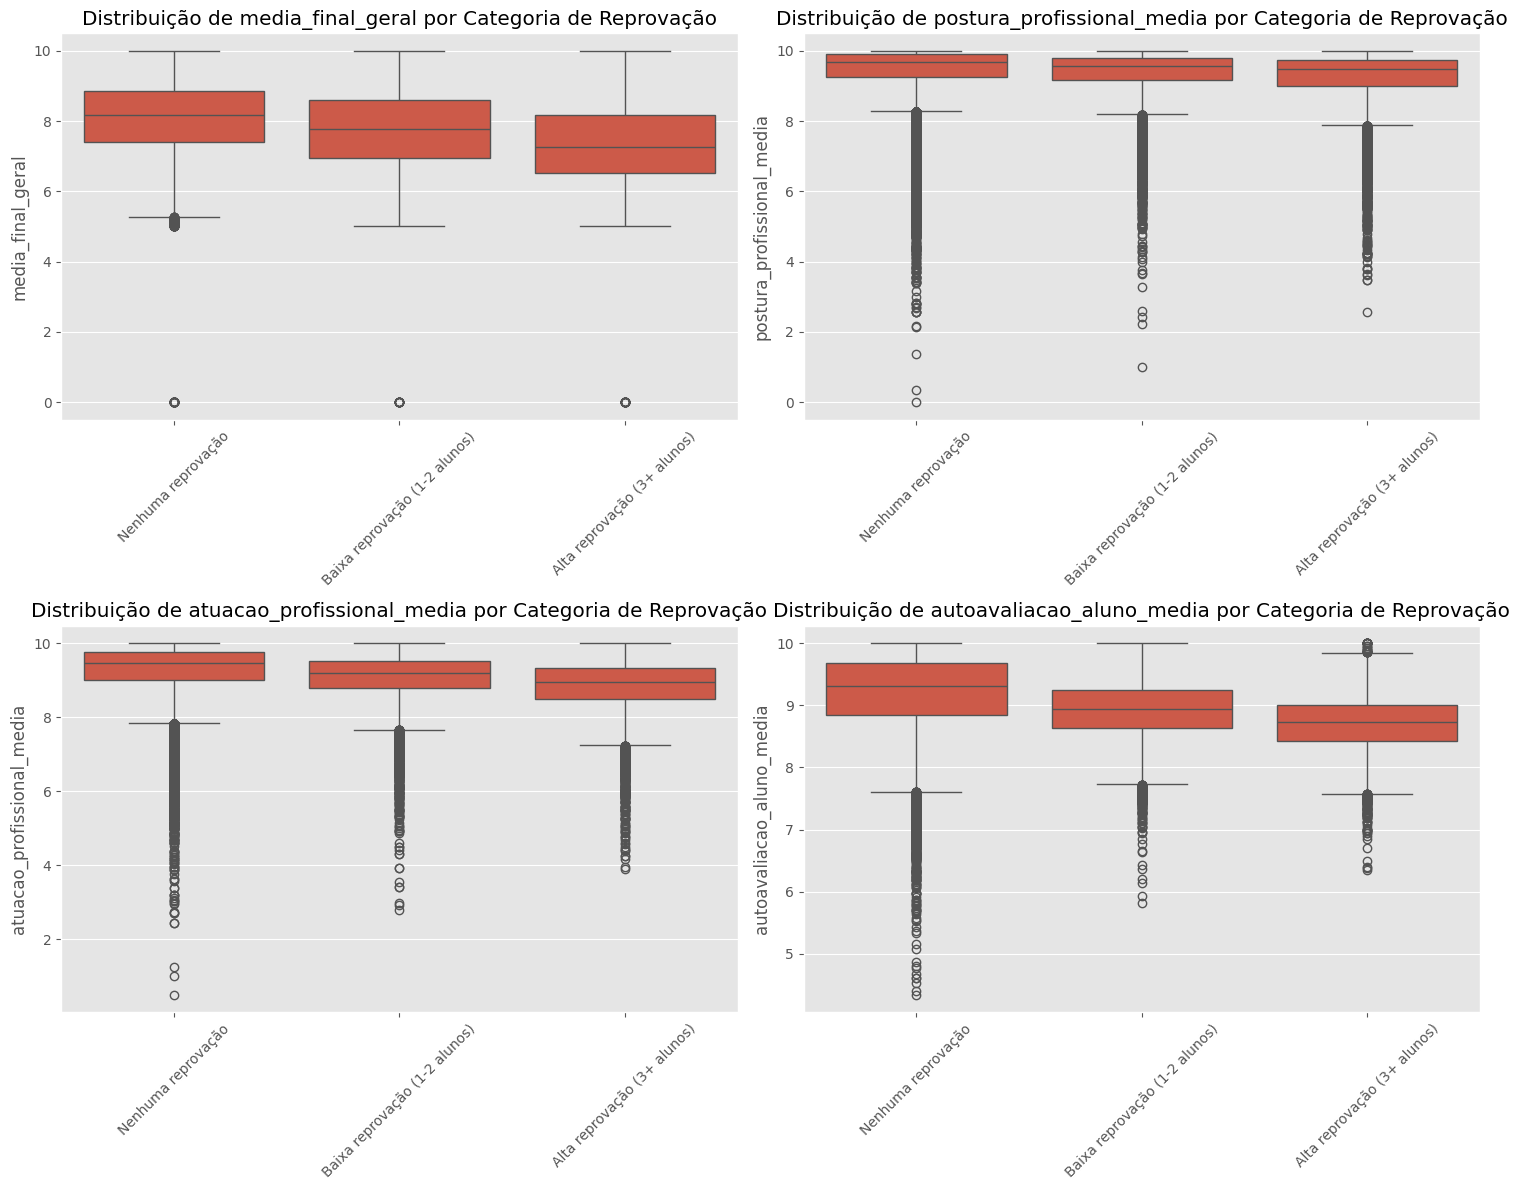

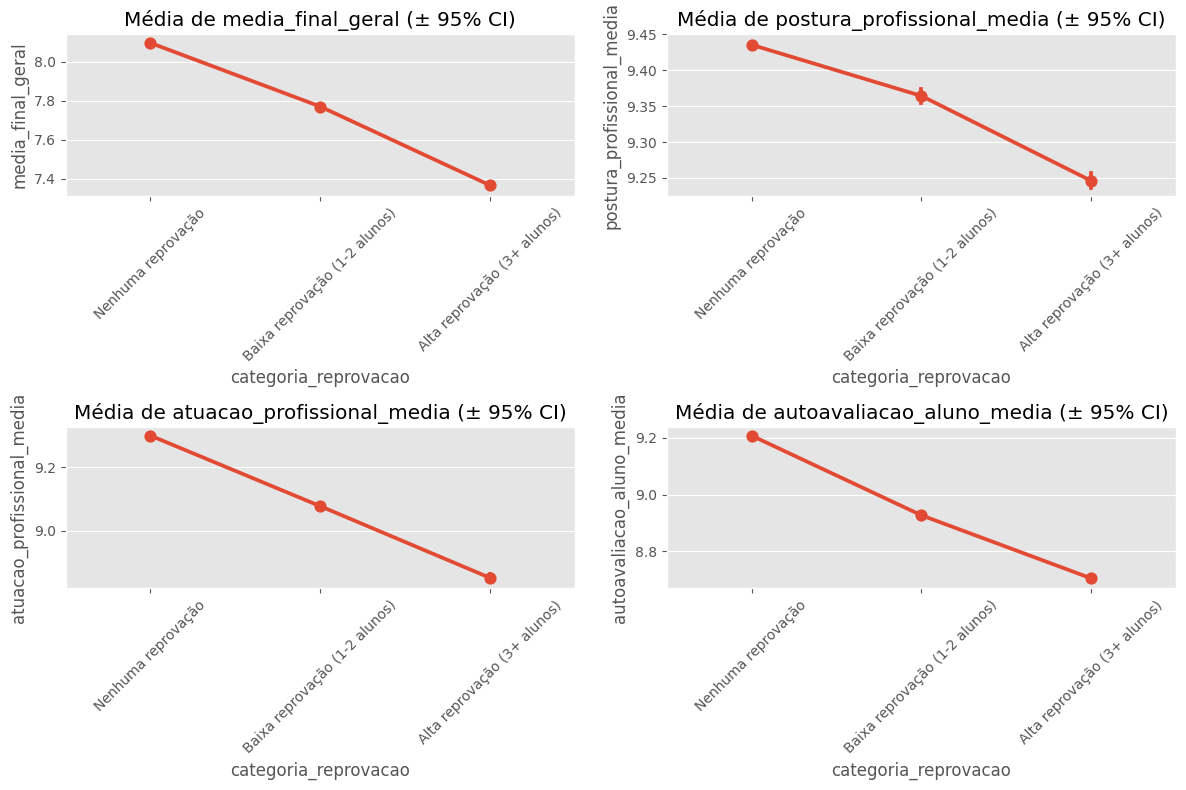

In [10]:
# Boxplot comparando os grupos
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, var in enumerate(variaveis_avaliacao):
    sns.boxplot(data=df, x='categoria_reprovacao', y=var, ax=axes[i])
    axes[i].set_title(f'Distribuição de {var} por Categoria de Reprovação')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

# Gráfico de médias com intervalos de confiança
plt.figure(figsize=(12, 8))
for i, var in enumerate(variaveis_avaliacao, 1):
    plt.subplot(2, 2, i)
    sns.pointplot(data=df, x='categoria_reprovacao', y=var, errorbar=('ci', 95))
    plt.title(f'Média de {var} (± 95% CI)')
    plt.xticks(rotation=45)
    
plt.tight_layout()
plt.show()